# Unidad 1 · Análisis del sistema de medición (MSA): estudio R&R

**Planta:** Conservas del Itata S.A. — balanza de peso escurrido
**Datos:** `DatosClases/1_Calidad/itata_msa.csv`
(10 piezas × 3 operadores × 2 repeticiones = 60 mediciones)

---

## Qué se decide aquí

Los dos cuadernos anteriores hicieron algo que conviene mirar con
desconfianza: tomaron los números de la balanza y los trataron como si fueran
el peso de los envases. No lo son. Son el peso **más** lo que el instrumento
agregó. Todo lo que se calculó —σ, límites de control, Cp, Cpk, PPM— está
contaminado por el error de medición, y hasta ahora no se sabe cuánto.

La pregunta que responde un estudio R&R es: de la variación que veo, ¿cuánta
viene del proceso y cuánta de la forma en que lo estoy midiendo? La decisión
que cuelga es doble:

* **antes de medir cualquier otra cosa**: ¿este instrumento sirve para la
  tolerancia que tengo que controlar? Si no discrimina, comparar turnos,
  máquinas o proveedores con él es comparar ruido con ruido, y la conclusión
  que se saque será tan firme como el sorteo que la produjo;
* **después**: ¿cuánto de mi Cp es real y cuánto es un artefacto de la
  balanza?

El orden importa y es el error de secuencia más común en la industria: se
monta el proyecto de mejora, se corren las cartas, se comparan los turnos, y
recién cuando los resultados no cierran alguien pregunta si la balanza estaba
bien. El R&R va **primero**.

## Las dos erres

* **Repetibilidad (EV, *equipment variation*)**: el mismo operador mide la
  misma pieza dos veces y obtiene números distintos. Es la variación del
  instrumento consigo mismo.
* **Reproducibilidad (AV, *appraiser variation*)**: distintos operadores miden
  la misma pieza y obtienen promedios distintos. Es el sesgo entre personas:
  dónde apoyan el envase, cómo escurren, cuánto esperan a que la lectura se
  estabilice.

Las dos juntas forman el GRR (*gage repeatability and reproducibility*), que
es la desviación estándar del sistema de medición completo.

## Cifras de referencia

| cantidad | valor |
|---|---|
| R̄̄ (rango medio de repeticiones) | 0,926 g |
| X̄_diff (rango de medias por operador) | 1,775 g |
| R_piezas (rango de medias por pieza) | 10,575 g |
| EV (repetibilidad) | 0,821 g |
| AV (reproducibilidad) | 0,910 g |
| GRR | 1,226 g |
| PV (variación entre piezas) | 3,327 g |
| TV (variación total) | 3,545 g |
| %GRR sobre TV | 34,6 % |
| %GRR sobre tolerancia | 24,5 % |
| ndc | 3,83 → 3 categorías |
| σ observado / σ proceso | 3,655 / 3,444 g |
| Cp observado / Cp verdadero | 1,368 / 1,452 (diferencia 0,084) |

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

LIE, LSE = 465.0, 495.0
TOLERANCIA = LSE - LIE

msa = pd.read_csv(datos("1_Calidad", "itata_msa.csv"))

N_PIEZAS = msa.pieza.nunique()
N_OPER = msa.operador.nunique()
N_REP = msa.repeticion.nunique()

print(f"{len(msa)} mediciones = {N_PIEZAS} piezas x {N_OPER} operadores "
      f"x {N_REP} repeticiones")
print(f"Tolerancia de la característica: {TOLERANCIA:.0f} g "
      f"[LIE {LIE:.0f} ; LSE {LSE:.0f}]")
msa.head()

60 mediciones = 10 piezas x 3 operadores x 2 repeticiones
Tolerancia de la característica: 30 g [LIE 465 ; LSE 495]


,pieza,operador,repeticion,medicion_g
0,1,A,1,483.97
1,1,A,2,485.36
2,1,B,1,486.19
3,1,B,2,484.98
4,1,C,1,483.08


## 1. Cómo se diseña el estudio, y por qué así

El diseño no es libre. Las 10 piezas deben elegirse para que **cubran el rango
de variación normal del proceso**, no para que sean parecidas: si todas las
piezas pesan casi lo mismo, el instrumento parecerá malísimo aunque esté
perfecto, porque no habrá nada que discriminar. Si se eligen demasiado
dispersas, parecerá excelente. El %GRR sobre la variación total es, por
construcción, relativo a las piezas elegidas.

Las repeticiones deben ser **ciegas y en orden aleatorio**: si el operador
recuerda que ese envase pesó 483,9 la primera vez, la segunda medición no es
independiente y la repetibilidad sale artificialmente buena. Y los tres
operadores deben ser los que efectivamente miden en planta, no los tres
mejores.

Antes de calcular nada, vale la pena mirar los datos crudos ordenados, porque
la mitad de los hallazgos de un R&R se ven a simple vista.

In [2]:
crudo = msa.pivot_table(index="pieza", columns=["operador", "repeticion"],
                        values="medicion_g")
print(crudo.round(2).to_string())

medias_op = msa.groupby("operador")["medicion_g"].mean()
print("\n  Media por operador:")
for o, v in medias_op.items():
    print(f"    {o}: {v:.3f} g")
print(f"\n  El operador B lee en promedio "
      f"{medias_op['B'] - medias_op['C']:.2f} g por sobre el C, "
      f"midiendo las MISMAS piezas.")

operador         A               B               C        
repeticion       1       2       1       2       1       2
pieza                                                     
1           483.97  485.36  486.19  484.98  483.08  482.87
2           491.19  488.68  491.93  491.37  490.35  489.70
3           479.48  480.79  480.73  479.83  479.60  479.34
4           481.46  480.98  480.62  481.49  481.45  481.02
5           479.92  480.89  481.31  481.81  481.36  481.63
6           486.65  484.81  487.00  486.84  485.85  484.09
7           483.47  482.31  483.41  483.97  481.23  481.87
8           484.14  483.51  485.03  484.01  482.41  482.36
9           481.97  483.82  483.17  482.57  481.49  479.86
10          485.14  485.71  489.39  487.17  484.17  483.59

  Media por operador:
    A: 483.712 g
    B: 484.641 g
    C: 482.866 g

  El operador B lee en promedio 1.77 g por sobre el C, midiendo las MISMAS piezas.


## 2. Repetibilidad: el instrumento contra sí mismo

El método de rangos de AIAG estima cada componente a partir de rangos, igual
que las cartas de control y por la misma razón histórica: se calcula a mano en
planta, sin software.

Para cada combinación pieza × operador se toma el rango de las repeticiones.
El promedio de esos 30 rangos, R̄̄, mide cuánto se mueve una medición repetida
en las mismas condiciones. Como E[R] = d₂σ, la conversión a desviación
estándar es una constante tabulada: **EV = K₁ · R̄̄**, donde K₁ = 0,8862 para
2 repeticiones (es 1/d₂ con d₂ = 1,128, la misma constante de la carta R
con n = 2).

In [3]:
K1 = 0.8862      # 2 repeticiones
K2 = 0.5231      # 3 operadores
K3 = 0.3146      # 10 piezas

piv = msa.pivot_table(index=["pieza", "operador"], columns="repeticion",
                      values="medicion_g")
piv["R"] = (piv[1] - piv[2]).abs()

rbb = piv["R"].mean()
EV = K1 * rbb

print(f"  Rangos de repetición por pieza x operador (primeros 6):")
print(piv.head(6).round(3).to_string())
print(f"\n  R-doble-barra = {rbb:.3f} g   (media de {len(piv)} rangos)")
print(f"  EV = K1 x R-doble-barra = {K1} x {rbb:.3f} = {EV:.3f} g")

  Rangos de repetición por pieza x operador (primeros 6):
repeticion           1       2     R
pieza operador                      
1     A         483.97  485.36  1.39
      B         486.19  484.98  1.21
      C         483.08  482.87  0.21
2     A         491.19  488.68  2.51
      B         491.93  491.37  0.56
      C         490.35  489.70  0.65

  R-doble-barra = 0.926 g   (media de 30 rangos)
  EV = K1 x R-doble-barra = 0.8862 x 0.926 = 0.821 g


## 3. Reproducibilidad: los operadores entre sí

La diferencia entre las medias de los operadores, X̄_diff, es la señal cruda de
reproducibilidad. Pero contiene un polizón: las medias de los operadores
difieren en parte por sesgo genuino y en parte porque cada medición ya trae
error de repetibilidad, y ese error no se cancela del todo al promediar. La
fórmula AIAG descuenta esa contribución:

$$AV = \sqrt{\max\left(0,\; (X_{diff}\,K_2)^2 - \frac{EV^2}{n_{piezas}\,n_{rep}}\right)}$$

El `max(0, ·)` no es una precaución cosmética: cuando el sesgo entre
operadores es pequeño frente al ruido del instrumento, el término descontado
supera al primero y el radicando se vuelve negativo. AIAG define AV = 0 en ese
caso, con una lectura clara: *no se detecta reproducibilidad por encima de lo
que explica el propio ruido de repetición*. Aquí no ocurre, porque el sesgo de
B es real.

In [4]:
Xdiff = medias_op.max() - medias_op.min()
correccion = EV ** 2 / (N_PIEZAS * N_REP)
AV = np.sqrt(max(0.0, (Xdiff * K2) ** 2 - correccion))
GRR = np.sqrt(EV ** 2 + AV ** 2)

print(f"  X-diff = {medias_op.max():.3f} - {medias_op.min():.3f} = {Xdiff:.3f} g")
print(f"\n  (X-diff x K2)^2 = ({Xdiff:.3f} x {K2})^2 = "
      f"{(Xdiff*K2)**2:.4f}")
print(f"  EV^2 / (n_piezas x n_rep) = {EV**2:.4f} / {N_PIEZAS*N_REP} = "
      f"{correccion:.4f}")
print(f"  AV = sqrt({(Xdiff*K2)**2:.4f} - {correccion:.4f}) = {AV:.3f} g")
print(f"\n  GRR = sqrt(EV^2 + AV^2) = sqrt({EV:.3f}^2 + {AV:.3f}^2) = {GRR:.3f} g")
print(f"\n  Reparto dentro del GRR:  "
      f"repetibilidad {100*EV**2/GRR**2:.0f} %   "
      f"reproducibilidad {100*AV**2/GRR**2:.0f} %")

  X-diff = 484.641 - 482.866 = 1.775 g

  (X-diff x K2)^2 = (1.775 x 0.5231)^2 = 0.8621
  EV^2 / (n_piezas x n_rep) = 0.6739 / 20 = 0.0337
  AV = sqrt(0.8621 - 0.0337) = 0.910 g

  GRR = sqrt(EV^2 + AV^2) = sqrt(0.821^2 + 0.910^2) = 1.226 g

  Reparto dentro del GRR:  repetibilidad 45 %   reproducibilidad 55 %


El reparto es casi mitad y mitad, y eso tiene consecuencias de gestión
distintas para cada mitad. La reproducibilidad se ataca con procedimiento y
entrenamiento: estandarizar el escurrido, definir el tiempo de espera de la
lectura, capacitar a B. Es barato. La repetibilidad se ataca con el
instrumento: calibración, mantenimiento, o una balanza mejor. Es caro. Un
estudio que reportara solo el GRR total escondería precisamente la
información que decide qué hacer.

## 4. Variación entre piezas y variación total

PV mide cuánto difieren las piezas entre sí —la señal que el instrumento debe
ser capaz de ver— y se estima del rango de las medias por pieza, con la
constante K₃ correspondiente a 10 piezas. TV es la variación total observada,
y bajo el supuesto de independencia entre el error de medición y el valor
verdadero, las varianzas se suman:

$$TV^2 = GRR^2 + PV^2$$

Esa suma de varianzas es el corazón conceptual de todo el cuaderno, y
reaparecerá en la sección 7 aplicada al proceso completo.

In [5]:
medias_pieza = msa.groupby("pieza")["medicion_g"].mean()
Rp = medias_pieza.max() - medias_pieza.min()
PV = K3 * Rp
TV = np.sqrt(GRR ** 2 + PV ** 2)

print(f"  Medias por pieza (g):")
print("    " + "  ".join(f"{v:.2f}" for v in medias_pieza))
print(f"\n  R_piezas = {medias_pieza.max():.3f} - {medias_pieza.min():.3f} "
      f"= {Rp:.3f} g")
print(f"  PV = K3 x R_piezas = {K3} x {Rp:.3f} = {PV:.3f} g")
print(f"  TV = sqrt(GRR^2 + PV^2) = sqrt({GRR:.3f}^2 + {PV:.3f}^2) = {TV:.3f} g")

  Medias por pieza (g):
    484.41  490.54  479.96  481.17  481.15  485.87  482.71  483.58  482.15  485.86

  R_piezas = 490.537 - 479.962 = 10.575 g
  PV = K3 x R_piezas = 0.3146 x 10.575 = 3.327 g
  TV = sqrt(GRR^2 + PV^2) = sqrt(1.226^2 + 3.327^2) = 3.545 g


## 5. Los dos porcentajes, y por qué no se pueden confundir

Aquí hay una trampa que cuesta puntos en las pruebas y proyectos reales en la
industria. Existen **dos** maneras de expresar el %GRR y responden preguntas
distintas:

* **%GRR sobre la variación total** = 100·GRR/TV. Pregunta: de lo que veo
  variar, ¿qué fracción es el instrumento? Sirve para decidir si el
  instrumento puede usarse para **estudiar el proceso** (comparar turnos,
  detectar corrimientos, estimar capacidad).
* **%GRR sobre la tolerancia** = 100·6·GRR/(LSE−LIE). Pregunta: ¿qué fracción
  del margen del cliente me consume el instrumento? Sirve para decidir si el
  instrumento puede usarse para **clasificar unidades** (aceptar o rechazar
  contra especificación).

Los dos números son distintos y aquí la diferencia es grande: 34,6 % contra
24,5 %. No se contradicen. Dicen que esta balanza es peor para estudiar el
proceso que para clasificar envases, porque la tolerancia de 30 g es ancha
comparada con lo que las piezas realmente varían. Reportar solo el número
conveniente es una forma silenciosa de mentir.

El criterio AIAG es el mismo para ambos: **< 10 % aceptable, 10–30 % marginal
(aceptable según el costo del instrumento y la criticidad), > 30 %
inaceptable**.

In [6]:
pct_tv = 100 * GRR / TV
pct_tol = 100 * 6 * GRR / TOLERANCIA


def veredicto(p):
    return ("ACEPTABLE" if p < 10 else
            "MARGINAL" if p <= 30 else "INACEPTABLE")


print(f"  %GRR sobre variación total = 100 x {GRR:.3f} / {TV:.3f} "
      f"= {pct_tv:.1f} %   -> {veredicto(pct_tv)}")
print(f"  %GRR sobre tolerancia      = 100 x 6 x {GRR:.3f} / {TOLERANCIA:.0f} "
      f"= {pct_tol:.1f} %   -> {veredicto(pct_tol)}")
print(f"\n  Descomposición sobre la variación total:")
for nom, v in [("EV  (repetibilidad)", EV), ("AV  (reproducibilidad)", AV),
               ("GRR (sistema de medición)", GRR), ("PV  (piezas)", PV)]:
    print(f"    {nom:<28} {v:6.3f} g   {100*v/TV:5.1f} % de TV")
print(f"\n  (Los porcentajes no suman 100: son razones de desviaciones,"
      f"\n   y lo que suma es la VARIANZA. "
      f"{(GRR/TV)**2*100:.0f} % + {(PV/TV)**2*100:.0f} % = 100 %.)")

  %GRR sobre variación total = 100 x 1.226 / 3.545 = 34.6 %   -> INACEPTABLE
  %GRR sobre tolerancia      = 100 x 6 x 1.226 / 30 = 24.5 %   -> MARGINAL

  Descomposición sobre la variación total:
    EV  (repetibilidad)           0.821 g    23.2 % de TV
    AV  (reproducibilidad)        0.910 g    25.7 % de TV
    GRR (sistema de medición)     1.226 g    34.6 % de TV
    PV  (piezas)                  3.327 g    93.8 % de TV

  (Los porcentajes no suman 100: son razones de desviaciones,
   y lo que suma es la VARIANZA. 12 % + 88 % = 100 %.)


## 6. ndc: cuántos escalones distingue la balanza

El %GRR dice si el instrumento es bueno; el **ndc** (*number of distinct
categories*) dice para qué alcanza, y es más intuitivo de explicar en planta.

$$ndc = 1{,}41 \cdot \frac{PV}{GRR}$$

Se interpreta como en cuántos grupos realmente distinguibles puede separar el
instrumento las piezas del proceso. El 1,41 ≈ √2 sale de exigir que dos
categorías estén separadas por un intervalo de confianza que no se traslape.
AIAG pide **ndc ≥ 5**, y el número se trunca, no se redondea: 3,83 categorías
no existen, existen 3.

Con 3 categorías esta balanza puede decir «liviano / normal / pesado» y nada
más. Eso es suficiente para separar un envase groseramente fuera de
especificación. No es suficiente para detectar un corrimiento de media de 6 g
repartido entre turnos, que es justamente lo que se le pidió en el cuaderno 1.

In [7]:
ndc = 1.41 * PV / GRR

print(f"  ndc = 1.41 x {PV:.3f} / {GRR:.3f} = {ndc:.2f}"
      f"  ->  {int(ndc)} categorías distinguibles")
print(f"  Criterio AIAG: ndc >= 5   ->  "
      f"{'CUMPLE' if ndc >= 5 else 'NO CUMPLE'}")
print(f"\n  Para llegar a ndc = 5 con el mismo PV haría falta "
      f"GRR <= {1.41*PV/5:.3f} g,")
print(f"  es decir reducir el sistema de medición un "
      f"{100*(1 - (1.41*PV/5)/GRR):.0f} %.")

  ndc = 1.41 x 3.327 / 1.226 = 3.83  ->  3 categorías distinguibles
  Criterio AIAG: ndc >= 5   ->  NO CUMPLE

  Para llegar a ndc = 5 con el mismo PV haría falta GRR <= 0.938 g,
  es decir reducir el sistema de medición un 23 %.


## 7. La parte que importa: cuánto Cp se come el instrumento

Todo lo anterior es diagnóstico del instrumento. Esta sección es la que
conecta el MSA con las decisiones de los cuadernos 1 y 2, y es la razón por la
que el R&R no es un trámite de auditoría.

Lo que la carta de control midió como σ = 3,655 g **no era la variación del
proceso**. Era la variación de las lecturas, que es la del proceso más la del
instrumento:

$$\sigma_{obs}^2 = \sigma_{proceso}^2 + \sigma_{medicion}^2$$

con σ_medición = GRR. Despejando se recupera la variación real del llenado. El
supuesto que lo permite es que el error de medición sea independiente del
valor verdadero —razonable en una balanza, no siempre cierto en un
instrumento cuyo error crece con la magnitud.

In [8]:
peso = pd.read_csv(datos("1_Calidad", "itata_peso.csv"))
sg1 = peso[peso.fase == "I"].groupby("subgrupo")["peso_g"]
sigma_obs = (sg1.max() - sg1.min()).mean() / 2.059   # R-barra/d2, cuaderno 1

sigma_proc = np.sqrt(max(0.0, sigma_obs ** 2 - GRR ** 2))

Cp_obs = TOLERANCIA / (6 * sigma_obs)
Cp_real = TOLERANCIA / (6 * sigma_proc)

print(f"  sigma observado (carta X-R, Fase I) = {sigma_obs:.3f} g")
print(f"  sigma de medición (GRR)             = {GRR:.3f} g")
print(f"\n  {sigma_obs:.3f}^2 = sigma_proceso^2 + {GRR:.3f}^2")
print(f"  {sigma_obs**2:.3f}   = sigma_proceso^2 + {GRR**2:.3f}")
print(f"  sigma_proceso = sqrt({sigma_obs**2 - GRR**2:.3f}) = {sigma_proc:.3f} g")
print(f"\n  Cp OBSERVADO  = {TOLERANCIA:.0f} / (6 x {sigma_obs:.3f})  = {Cp_obs:.3f}")
print(f"  Cp VERDADERO  = {TOLERANCIA:.0f} / (6 x {sigma_proc:.3f})  = {Cp_real:.3f}")
print(f"\n  El instrumento se come {Cp_real - Cp_obs:.3f} de Cp.")
print(f"  El {100*(1 - sigma_proc/sigma_obs):.1f} % del sigma reportado no era"
      f" del llenado: era de la balanza.")

  sigma observado (carta X-R, Fase I) = 3.655 g
  sigma de medición (GRR)             = 1.226 g

  3.655^2 = sigma_proceso^2 + 1.226^2
  13.360   = sigma_proceso^2 + 1.502
  sigma_proceso = sqrt(11.858) = 3.444 g

  Cp OBSERVADO  = 30 / (6 x 3.655)  = 1.368
  Cp VERDADERO  = 30 / (6 x 3.444)  = 1.452

  El instrumento se come 0.084 de Cp.
  El 5.8 % del sigma reportado no era del llenado: era de la balanza.


Dos lecturas, y conviene no quedarse solo con la primera.

La optimista: el llenado es mejor de lo que parecía. Parte del «problema de
variabilidad» es en realidad un problema de balanza, y arreglar la balanza es
más barato que intervenir la llenadora.

La incómoda: **el efecto sobre Cp es pequeño**, 0,084. Con un GRR que es el
34,6 % de la variación total uno esperaría un desastre, y no lo es. La razón
es que las varianzas se suman en cuadrado: un GRR que es un tercio de σ_obs
aporta solo un noveno de la varianza. Esta es la intuición que hay que fijar
en la clase: **los componentes de variación no se suman como uno cree**, y por
eso el instinto de «34 % de error de medición arruina todo» es incorrecto.

Lo que el instrumento sí arruina es la capacidad de **discriminar**: ndc = 3.
Para estimar un Cp global la balanza alcanza; para comparar dos turnos que
difieren en 1 g, no. El daño del error de medición no está tanto en el sesgo
de los índices como en la potencia de las comparaciones.

## 8. Contraste: el mismo estudio por ANOVA

El método de rangos se inventó para hacerse a mano. Con software, el estudio
estándar es un ANOVA de dos factores con interacción: pieza (aleatorio),
operador (aleatorio) y la interacción pieza×operador, que captura el caso en
que un operador mide distinto *según la pieza* —algo que el método de rangos
no puede ni ver, porque lo absorbe dentro de la repetibilidad.

El ANOVA además da inferencia: permite preguntar si el sesgo entre operadores
es distinguible del ruido, en lugar de solo cuantificarlo.

In [9]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

mod = ols("medicion_g ~ C(pieza) * C(operador)",
          data=msa.assign(pieza=msa.pieza.astype(str))).fit()
aov = sm.stats.anova_lm(mod, typ=2)
print(aov.round(4).to_string())

ms = aov["sum_sq"] / aov["df"]
ms_pieza, ms_oper = ms.iloc[0], ms.iloc[1]
ms_inter, ms_error = ms.iloc[2], ms.iloc[3]

var_rep = ms_error
var_inter = max(0.0, (ms_inter - ms_error) / N_REP)
var_oper = max(0.0, (ms_oper - ms_inter) / (N_PIEZAS * N_REP))
var_pieza = max(0.0, (ms_pieza - ms_inter) / (N_OPER * N_REP))

EV_a = np.sqrt(var_rep)
AV_a = np.sqrt(var_oper + var_inter)
GRR_a = np.sqrt(EV_a ** 2 + AV_a ** 2)
PV_a = np.sqrt(var_pieza)
TV_a = np.sqrt(GRR_a ** 2 + PV_a ** 2)

cmp = pd.DataFrame({
    "componente": ["EV", "AV", "GRR", "PV", "TV", "%GRR sobre TV"],
    "metodo_rangos": [EV, AV, GRR, PV, TV, pct_tv],
    "ANOVA": [EV_a, AV_a, GRR_a, PV_a, TV_a, 100 * GRR_a / TV_a],
})
print("\n" + cmp.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))
p_inter = aov["PR(>F)"].iloc[2]
print(f"\n  p-valor de la interacción pieza x operador: {p_inter:.3f}")

                        sum_sq    df        F  PR(>F)
C(pieza)              521.3506   9.0  92.5545  0.0000
C(operador)            31.5287   2.0  25.1875  0.0000
C(pieza):C(operador)   21.3923  18.0   1.8989  0.0584
Residual               18.7763  30.0      NaN     NaN

   componente  metodo_rangos     ANOVA
           EV          0.821     0.791
           AV          0.910     1.005
          GRR          1.226     1.279
           PV          3.327     3.075
           TV          3.545     3.331
%GRR sobre TV         34.570    38.404

  p-valor de la interacción pieza x operador: 0.058


Los dos métodos dan números del mismo orden, y eso es lo esperable: el método
de rangos es una aproximación deliberadamente tosca de lo mismo. Las
diferencias tienen causas identificables —el ANOVA separa la interacción, que
el método de rangos mete dentro de EV; y el método de rangos usa rangos en
lugar de sumas de cuadrados, que es menos eficiente con pocos datos—, no son
un error de cálculo.

El p-valor de la interacción es alto: no hay evidencia de que algún operador
mida distinto según la pieza. El problema de reproducibilidad es un **sesgo
constante** del operador B, que es la buena noticia: un sesgo constante se
corrige con procedimiento y entrenamiento. Una interacción significativa
habría sido mucho peor, porque significa que el operador introduce un error
que depende de lo que mide, y eso no se corrige con una instrucción.

La conclusión práctica no cambia con el método: la balanza es marginal y no
discrimina.

## 9. El gráfico: componentes de varianza y dispersión por operador

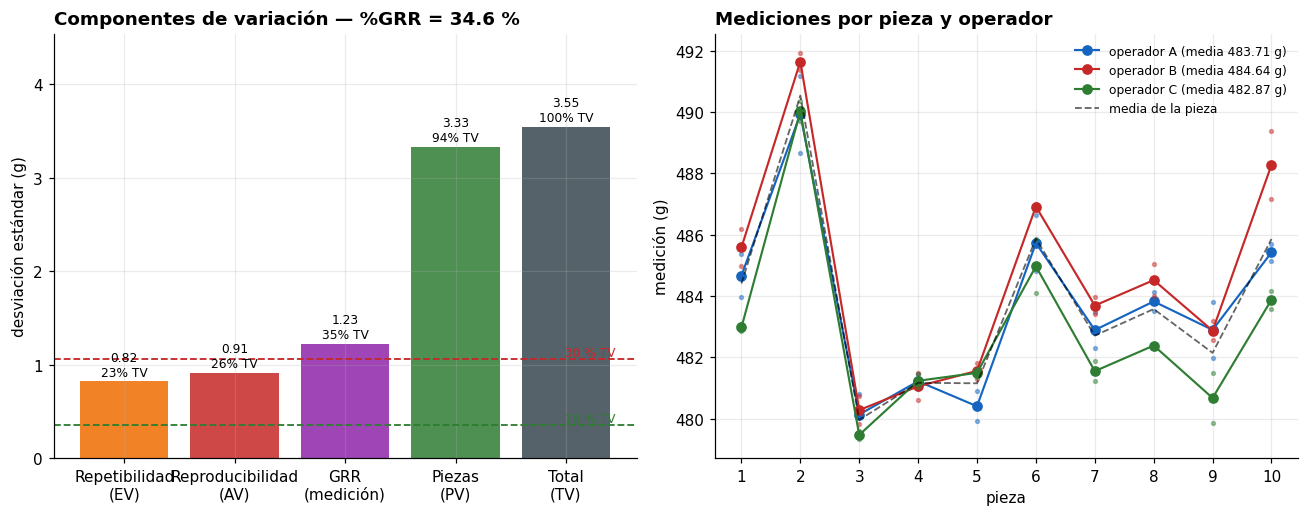

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))

# --- izquierda: componentes de varianza
comps = [("Repetibilidad\n(EV)", EV, "#ef6c00"),
         ("Reproducibilidad\n(AV)", AV, "#c62828"),
         ("GRR\n(medición)", GRR, "#8e24aa"),
         ("Piezas\n(PV)", PV, "#2e7d32"),
         ("Total\n(TV)", TV, "#37474f")]
nombres = [c[0] for c in comps]
valores = [c[1] for c in comps]
colores = [c[2] for c in comps]

barras = ax[0].bar(nombres, valores, color=colores, alpha=0.85)
for b, v in zip(barras, valores):
    ax[0].text(b.get_x() + b.get_width() / 2, v + 0.06,
               f"{v:.2f}\n{100*v/TV:.0f}% TV", ha="center", fontsize=8)
ax[0].axhline(0.10 * TV, color="#2e7d32", ls="--", lw=1.2)
ax[0].axhline(0.30 * TV, color="#c62828", ls="--", lw=1.2)
ax[0].text(4.45, 0.10 * TV, " 10 % TV", color="#2e7d32", fontsize=8, va="bottom",
           ha="right")
ax[0].text(4.45, 0.30 * TV, " 30 % TV", color="#c62828", fontsize=8, va="bottom",
           ha="right")
ax[0].set_ylabel("desviación estándar (g)")
ax[0].set_ylim(0, TV * 1.28)
ax[0].set_title(f"Componentes de variación — %GRR = {pct_tv:.1f} %", loc="left")

# --- derecha: mediciones por pieza y operador
colores_op = {"A": "#1565c0", "B": "#c62828", "C": "#2e7d32"}
for op, g in msa.groupby("operador"):
    m = g.groupby("pieza")["medicion_g"].mean()
    ax[1].plot(m.index, m.values, "o-", color=colores_op[op], ms=6, lw=1.4,
               label=f"operador {op} (media {medias_op[op]:.2f} g)")
    ax[1].plot(g.pieza, g.medicion_g, ".", color=colores_op[op], ms=5,
               alpha=0.45)
ax[1].plot(medias_pieza.index, medias_pieza.values, "k--", lw=1.2, alpha=0.6,
           label="media de la pieza")
ax[1].set_xlabel("pieza")
ax[1].set_ylabel("medición (g)")
ax[1].set_xticks(range(1, N_PIEZAS + 1))
ax[1].set_title("Mediciones por pieza y operador", loc="left")
ax[1].legend(fontsize=8, loc="best")

figura(fig, "msa_componentes")
plt.show()

El panel derecho muestra las dos erres a la vez, y conviene leerlo en clase
antes que ningún número. La **separación vertical constante** entre las tres
líneas es la reproducibilidad: B corre por arriba en casi todas las piezas,
C por abajo, y el patrón se mantiene pieza a pieza —eso es un sesgo, no un
accidente. La **dispersión de los puntos tenues** alrededor de cada línea es
la repetibilidad. Y que las tres líneas suban y bajen juntas es lo único
tranquilizador del gráfico: los operadores están viendo la misma señal, solo
que corrida.

Compárese la altura de la banda que ocupan las tres líneas con la amplitud
vertical total del gráfico: esa razón es, a ojo, el %GRR.

## 10. Comprobación contra las cifras de referencia

In [11]:
print("Comprobación:")
ok = [
    verificar(rbb, 0.926, "R-doble-barra"),
    verificar(Xdiff, 1.775, "X-diff (medias por operador)"),
    verificar(Rp, 10.575, "R_piezas"),
    verificar(EV, 0.821, "EV (repetibilidad)"),
    verificar(AV, 0.910, "AV (reproducibilidad)"),
    verificar(GRR, 1.226, "GRR"),
    verificar(PV, 3.327, "PV"),
    verificar(TV, 3.545, "TV"),
    verificar(pct_tv, 34.6, "%GRR sobre variación total", tol=1e-2),
    verificar(pct_tol, 24.5, "%GRR sobre tolerancia", tol=1e-2),
    verificar(ndc, 3.83, "ndc"),
    verificar(sigma_proc, 3.444, "sigma del proceso (descontado GRR)"),
    verificar(Cp_obs, 1.368, "Cp observado"),
    verificar(Cp_real, 1.452, "Cp verdadero"),
    verificar(Cp_real - Cp_obs, 0.084, "Cp que se come el instrumento", tol=1e-2),
]
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")
assert all(ok), "alguna comprobación no reprodujo la cifra de referencia"
assert int(ndc) == 3, f"se esperaban 3 categorías, salieron {int(ndc)}"

componentes = pd.DataFrame({
    "componente": ["EV", "AV", "GRR", "PV", "TV"],
    "sigma_g": [EV, AV, GRR, PV, TV],
    "pct_TV": [100 * v / TV for v in (EV, AV, GRR, PV, TV)],
    "pct_tolerancia": [100 * 6 * v / TOLERANCIA for v in (EV, AV, GRR, PV, TV)],
})
tabla(componentes, "msa_componentes")
tabla(piv.reset_index(), "msa_rangos")
resumen({"R_doble_barra": rbb, "X_diff": Xdiff, "R_piezas": Rp,
         "EV": EV, "AV": AV, "GRR": GRR, "PV": PV, "TV": TV,
         "pct_GRR_TV": pct_tv, "pct_GRR_tolerancia": pct_tol,
         "ndc": ndc, "categorias": int(ndc),
         "sigma_observado": sigma_obs, "sigma_proceso": sigma_proc,
         "Cp_observado": Cp_obs, "Cp_verdadero": Cp_real,
         "veredicto_AIAG": veredicto(pct_tv)},
        "resumen_msa")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] R-doble-barra: obtenido 0.9263 | referencia 0.9260 | dif. relativa 3.33e-04
  [  OK  ] X-diff (medias por operador): obtenido 1.7750 | referencia 1.7750 | dif. relativa 1.28e-14
  [  OK  ] R_piezas: obtenido 10.5750 | referencia 10.5750 | dif. relativa 4.37e-15
  [  OK  ] EV (repetibilidad): obtenido 0.8209 | referencia 0.8210 | dif. relativa 8.34e-05
  [  OK  ] AV (reproducibilidad): obtenido 0.9102 | referencia 0.9100 | dif. relativa 1.77e-04
  [  OK  ] GRR: obtenido 1.2257 | referencia 1.2260 | dif. relativa 2.50e-04
  [  OK  ] PV: obtenido 3.3269 | referencia 3.3270 | dif. relativa 3.16e-05
  [  OK  ] TV: obtenido 3.5455 | referencia 3.5450 | dif. relativa 1.40e-04
  [  OK  ] %GRR sobre variación total: obtenido 34.5704 | referencia 34.6000 | dif. relativa 8.55e-04
  [  OK  ] %GRR sobre tolerancia: obtenido 24.5139 | referencia 24.5000 | dif. relativa 5.67e-04
  [  OK  ] ndc: obtenido 3.8272 | referencia 3.8300 | dif. relativa 7.43e-04
  [  OK  ] sigma del 

---

## Para llevarse

1. **Medir mal es una forma de variación, y se confunde con la del proceso.**
   El σ = 3,655 g de la carta de control no era del llenado: 1,226 g de él
   eran de la balanza. Ningún análisis posterior distingue un origen del otro
   si no se hace el R&R.
2. **El R&R va primero.** Con ndc = 3, esta balanza separa las piezas en
   liviano/normal/pesado y nada más. Cualquier comparación entre turnos,
   máquinas o proveedores hecha con ella es una comparación de ruido, y se
   concluirá lo que el azar quiera.
3. **Los dos %GRR responden preguntas distintas.** 34,6 % sobre la variación
   total (inaceptable para estudiar el proceso) y 24,5 % sobre la tolerancia
   (marginal para clasificar envases). Reportar solo el conveniente es mentir
   con datos correctos.
4. **Las varianzas se suman en cuadrado, y eso es contraintuitivo.** Un GRR
   que es un tercio de σ_obs solo se come 0,084 de Cp. El error de medición
   daña más la *potencia para comparar* que el *sesgo de los índices*.

## Ejercicios

1. El operador B lee en promedio 0,93 g por sobre A y 1,78 g por sobre C.
   Suponga que se lo capacita y su sesgo desaparece por completo: reste a
   todas las mediciones de B la diferencia respecto de la media general,
   vuelva a correr el estudio y reporte el nuevo AV, GRR, %GRR y ndc.
   ¿Alcanza el entrenamiento para dejar el instrumento en zona aceptable, o
   hay que cambiar la balanza igual?
2. Repita el estudio usando solo 5 piezas (las de índice impar). La constante
   K₃ para 5 piezas es 0,4030. ¿Cómo cambia el PV y, con él, el %GRR sobre la
   variación total? ¿Cambia el %GRR sobre la tolerancia? Explique por qué uno
   de los dos es sensible a la elección de piezas y el otro no, y qué
   consecuencia tiene eso para quien diseña el estudio.
3. Con σ_proceso = 3,444 g y el GRR actual, calcule qué Cpk habría reportado
   el cuaderno 2 si hubiera usado el σ verdadero en lugar del observado
   (manteniendo X̄̄ = 485,794 g). Luego responda: ¿cuál de los dos números hay
   que poner en el informe al cliente, y por qué? Justifique pensando en qué
   recibe efectivamente el cliente.